    # This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click !here goes the icon of the corresponding button in the gutter! button.
To debug a cell, press Alt+Shift+Enter, or click !here goes the icon of the corresponding button in the gutter! button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/jupyter-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
import os
import torch
import torchvision
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split

In [5]:
print(os.listdir())
print(os.listdir("new_train"))

['.idea', 'data', 'facialexpression.pth', 'MehaCrut.ipynb', 'message_data', 'models', 'new_train', 'output1.png', 'output2.png', 'output3.png', 'README.md', 'requirements.txt', 'sample.ipynb', 'test', 'train']
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [2]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor

In [3]:
dataset = ImageFolder('new_train', transform=ToTensor())

In [8]:
print(dataset[10])
print(dataset.classes)

(tensor([[[0.5647, 0.5686, 0.5647,  ..., 0.5686, 0.5569, 0.9451],
         [0.5608, 0.5647, 0.5647,  ..., 0.5843, 0.5961, 0.9137],
         [0.5569, 0.5647, 0.5647,  ..., 0.5765, 0.5804, 0.7373],
         ...,
         [0.0706, 0.0745, 0.0745,  ..., 0.4627, 0.4275, 0.4431],
         [0.0784, 0.0549, 0.0824,  ..., 0.0627, 0.0627, 0.0745],
         [0.0745, 0.0824, 0.0824,  ..., 0.0471, 0.0510, 0.0353]],

        [[0.6000, 0.6039, 0.5961,  ..., 0.5922, 0.5804, 0.9686],
         [0.5961, 0.5961, 0.5961,  ..., 0.6078, 0.6196, 0.9373],
         [0.5882, 0.5961, 0.5961,  ..., 0.6118, 0.6157, 0.7725],
         ...,
         [0.1529, 0.1490, 0.1412,  ..., 0.5059, 0.4706, 0.4863],
         [0.1412, 0.1216, 0.1412,  ..., 0.1294, 0.1294, 0.1412],
         [0.1333, 0.1412, 0.1373,  ..., 0.1255, 0.1255, 0.1098]],

        [[0.4314, 0.4353, 0.4431,  ..., 0.4824, 0.4784, 0.8667],
         [0.4275, 0.4353, 0.4431,  ..., 0.4980, 0.5176, 0.8353],
         [0.4275, 0.4353, 0.4431,  ..., 0.4902, 0.5020, 0

In [4]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

matplotlib.rcParams['figure.facecolor'] = '#ffffff'

In [5]:
def show_example(img, label):
    print('Label: ', dataset.classes[label], "("+str(label)+")")
    plt.imshow(img.permute(1, 2, 0))

Label:  disgust (2)


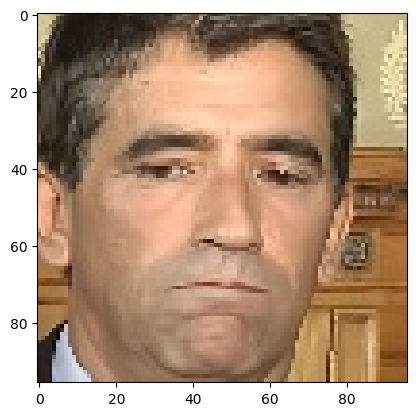

In [6]:
show_example(*dataset[6500])

In [12]:
random_seed = 50
torch.manual_seed(random_seed)

In [13]:
val_size = 2800
test_size = 2800
train_size = len(dataset) - val_size - test_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
len(train_ds), len(val_ds), len(test_ds)

(23442, 2800, 2800)

In [14]:
from torch.utils.data.dataloader import DataLoader

In [15]:
batch_size=128
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size*2, num_workers=4, pin_memory=True)
for i in train_dl:
  print(i)
  break

[tensor([[[[0.6745, 0.5490, 0.4784,  ..., 0.4078, 0.4157, 0.4196],
          [0.6078, 0.4745, 0.4314,  ..., 0.4039, 0.4118, 0.4118],
          [0.8000, 0.8275, 0.7961,  ..., 0.3922, 0.3882, 0.3765],
          ...,
          [0.2235, 0.1843, 0.1765,  ..., 0.6196, 0.0902, 0.1922],
          [0.1961, 0.2000, 0.1569,  ..., 0.0863, 0.1725, 0.1255],
          [0.1843, 0.1804, 0.1647,  ..., 0.4863, 0.4784, 0.5804]],

         [[0.6078, 0.4863, 0.4314,  ..., 0.4078, 0.4196, 0.4235],
          [0.5451, 0.4235, 0.3922,  ..., 0.4039, 0.4157, 0.4157],
          [0.7451, 0.7804, 0.7608,  ..., 0.3922, 0.3922, 0.3804],
          ...,
          [0.1647, 0.1294, 0.1373,  ..., 0.6157, 0.0745, 0.1725],
          [0.1412, 0.1647, 0.1373,  ..., 0.0784, 0.1569, 0.1098],
          [0.1412, 0.1529, 0.1490,  ..., 0.4863, 0.4627, 0.5647]],

         [[0.5451, 0.4275, 0.3843,  ..., 0.4157, 0.4275, 0.4314],
          [0.4863, 0.3608, 0.3529,  ..., 0.4118, 0.4235, 0.4235],
          [0.6941, 0.7255, 0.7255,  ..., 

In [16]:
from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=16).permute(1, 2, 0))
        break

In [3]:
show_batch(train_dl)

NameError: name 'show_batch' is not defined

In [4]:
import torch.nn as nn
import torch.nn.functional as F

In [19]:
simple_model = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
    nn.MaxPool2d(2, 2)
)

In [20]:
for images, labels in train_dl:
    print('images.shape:', images.shape)
    out = simple_model(images)
    print('out.shape:', out.shape)
    break

images.shape: torch.Size([128, 3, 96, 96])
out.shape: torch.Size([128, 8, 48, 48])


In [8]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [5]:
class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))

In [6]:
class Cifar10CnnModel(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 93, kernel_size=4, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 256 x 48 x 48

            nn.Conv2d(93, 256, kernel_size=4, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 400, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 384 x 24 x 24

            nn.Conv2d(400, 400, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(400, 256, kernel_size=2, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 256 x 12 x 12

            nn.Flatten(),
            nn.Linear(256 * 12 * 12, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 8))

    def forward(self, xb):
        return self.network(xb)

In [24]:
model = Cifar10CnnModel()
model

Cifar10CnnModel(
  (network): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 93, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(93, 256, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(256, 400, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(400, 400, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(400, 256, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=36864, out_features=1024, bias=True)
    (17): ReLU()
    (18): Linear(in_fea

In [25]:
for images, labels in train_dl:
    print('images.shape:', images.shape)
    out = model(images)
    print('out.shape:', out.shape)
    print('out[0]:', out[0])
    break

images.shape: torch.Size([128, 3, 96, 96])
out.shape: torch.Size([128, 8])
out[0]: tensor([-0.0011,  0.0276,  0.0492,  0.0093,  0.0145, -0.0135, -0.0173,  0.0147],
       grad_fn=<SelectBackward0>)


In [7]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [8]:
device = get_default_device()
device

device(type='cpu')

In [28]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device)

Cifar10CnnModel(
  (network): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 93, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(93, 256, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(256, 400, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(400, 400, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(400, 256, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=36864, out_features=1024, bias=True)
    (17): ReLU()
    (18): Linear(in_fea

In [9]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    models = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
        models.append(model)
    return history, models

In [30]:
model = to_device(MegaKrut(), device)

In [32]:
evaluate(model, val_dl)

{'val_loss': 2.0799052715301514, 'val_acc': 0.1884469836950302}

In [33]:
num_epochs = 7
opt_func = torch.optim.Adam
lr = 0.0025

In [34]:
history = fit(num_epochs, lr, model, train_dl, val_dl, opt_func)

KeyboardInterrupt: 

In [232]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs')

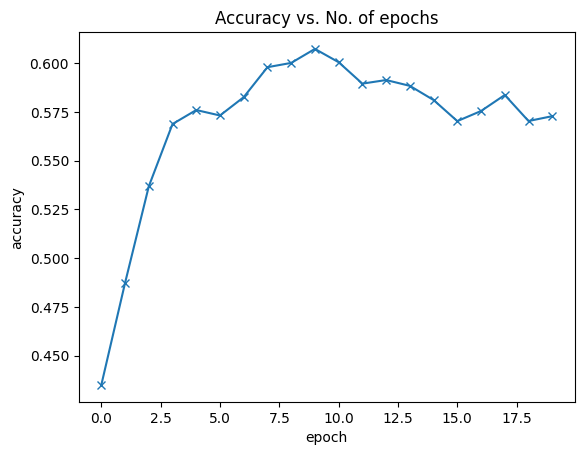

In [233]:
plot_accuracies(history)

In [31]:
test_dataset = ImageFolder('test', transform=ToTensor())

In [10]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return preds[0].item()

In [259]:
model = torch.load("models\\facialexpression2.pth")
test_loader = DeviceDataLoader(DataLoader(test_ds, batch_size*2), device)
result = evaluate(model, test_loader)
result 

{'val_loss': 0.6095767617225647, 'val_acc': 0.8920691013336182}

Label: contempt , Predicted: 1
tensor([[[0.8941, 0.8784, 0.8745,  ..., 0.9412, 0.9412, 0.9412],
         [0.8941, 0.8784, 0.8510,  ..., 0.9412, 0.9412, 0.9412],
         [0.8667, 0.8588, 0.8667,  ..., 0.9451, 0.9451, 0.9451],
         ...,
         [0.0667, 0.0353, 0.0353,  ..., 1.0000, 1.0000, 1.0000],
         [0.0510, 0.0235, 0.2392,  ..., 1.0000, 1.0000, 1.0000],
         [0.0196, 0.0431, 0.2353,  ..., 1.0000, 1.0000, 1.0000]],

        [[0.8941, 0.8784, 0.8706,  ..., 0.9451, 0.9451, 0.9451],
         [0.8941, 0.8784, 0.8471,  ..., 0.9451, 0.9451, 0.9451],
         [0.8627, 0.8549, 0.8510,  ..., 0.9490, 0.9490, 0.9490],
         ...,
         [0.0510, 0.0196, 0.0196,  ..., 1.0000, 1.0000, 1.0000],
         [0.0353, 0.0078, 0.2235,  ..., 1.0000, 1.0000, 1.0000],
         [0.0039, 0.0275, 0.2196,  ..., 1.0000, 1.0000, 1.0000]],

        [[0.8863, 0.8706, 0.8627,  ..., 0.9529, 0.9529, 0.9529],
         [0.8863, 0.8706, 0.8392,  ..., 0.9529, 0.9529, 0.9529],
         [0.8549, 0.8471, 0

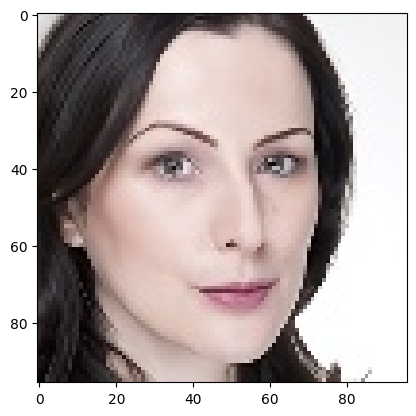

In [240]:
img, label = test_ds[32]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))
print(img)

In [11]:
import io
import random
import os

def get_random_word(fname):
  f = io.open(fname, mode="r", encoding="utf-8")
  all_words = f.read().split('\n')
  return all_words[random.randint(0, len(all_words) - 1)]


def get_greeting():
	greeting_fname = "message_data\\greetings.txt"
	return get_random_word(greeting_fname)


def get_insult():
	insult_fname = "message_data\\insults.txt"
	return get_random_word(insult_fname)


def main():
	print(get_insult())
	print(get_greeting())


In [12]:
from io import BytesIO
from PIL import Image



def get_image_from_bytes(b):
     stream = BytesIO(b)
     image = Image.open(stream).convert("RGB")
     stream.close()
     return image


def nuar_filter(image):
     pix = image.load()
     min_average, max_average = 255, 0
     for x in range(0, image.width):
          for y in range(0, image.height):
               average = int(sum(pix[x, y]) / 3)
               min_average = min(min_average, average)
               max_average = max(max_average, average)
               pix[x, y] = (average, average, average)
     if min_average == max_average:
          max_average += 1
     for x in range(0, image.width):
          for y in range(0, image.height):
               color = int((pix[x, y][0] - min_average) * 255 / (max_average - min_average))
               pix[x, y] = (color, color, color, 255)
     return image


def convert_to_96x96(image):
    '''
    w, h = image.size
    if w > 150 and h > 150:
        if w < h:
            image = image.crop((0, (h - w) / 2, w, h - (h - w) / 2))
        else:
            image = image.corp(((w - h) / 2, 0, w - (w - h) / 2, h))
    '''
    return image.resize((96, 96))

In [13]:
bots_model = torch.load('models\\facialexpression2.pth')


def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')


device = get_default_device()


def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)


def load_model():
    bots_model = torch.load('models\\facialexpression2.pth')
    print('loaded')


def get_result(image):
    print("getting result")
    loh = ImageFolder('photo', transform=ToTensor())
    return predict_image(loh[0][0], bots_model)

In [ ]:
import telebot
from io import BytesIO
from PIL import Image


TOKEN = '7109569189:AAFhDbZ4J3GVjex9qMMC4EuPHmDvc1I-iwE'

bot = telebot.TeleBot(TOKEN)


@bot.message_handler(commands=['start'])
def start(message):
    print(f"{message.from_user.first_name} started a bot")
    bot.send_message(message.chat.id, text=get_greeting())


@bot.message_handler(content_types=['text'])
def get_text_messages(message):
    print(f"{message.from_user.first_name} sent message: {message.text}")

    answer = get_insult() + '\nотправьте изображение'
    bot.send_message(message.chat.id, answer)
    print(f"{message.from_user.first_name} received message: {answer}")


@bot.message_handler(content_types=["photo"])
def get_text_messages(message):
    print(f"{message.from_user.first_name} sended an image")

    photo_id = message.photo[-1].file_id
    photo_file = bot.get_file(photo_id)
    photo_bytes = bot.download_file(photo_file.file_path)

    image = get_image_from_bytes(photo_bytes)
    image = convert_to_96x96(image)
    # image = nuar_filter(image)

    # convert image to result
    # then send result to user

    image.save("photo\\loh_kto_prochital_hahahah_popa\\input.png")

    index = get_result(image)
    emo_list = ["злость", "презрение", "отвращение", "испуг", "счастье", "нейтральность", "разочарование", "удивление!"]
    dirs = ["anger.txt", "contemptness.txt", "disgust.txt", "fear.txt", "happyness.txt", "netural.txt", "sadness.txt", "suprised.txt"]
    path = "message_data\\" + dirs[index]
    result = get_random_word(path)
    print(f"predicted: {emo_list[index]}")
    print(f"{message.from_user.first_name} got result: {result}")

    #bot.send_photo(message.chat.id, image)
    bot.send_message(message.chat.id, result)
    if result == "сигма":
        bot.send_photo(message.chat.id, Image.open("photo\\sigma.jfif"))


def start_bot():
    print('bot started')
    load_model()
    bot.infinity_polling(none_stop = True)
    print('bot ended')

def main():
	start_bot()                                     ''

main()